# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA & DLinear 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1. 시계열의 정상성은 평균과 분산 같은 통계적 특성이 일정한 상태를 의미하며, 과거 패턴을 미래 예측에 안정적으로 적용하기 위한 필수 전제조건이다. 정상성이 없는 데이터는 단순 추세 때문에 허구적 상관관계가 나타나는 Spurious Regression를 유발해 모델의 신뢰도를 떨어뜨린다.  ARIMA 모델은 차분을 통해 추세를 제거하고 평균을 일정하게 맞춤으로써 비정상성을 처리한다. 또한, 시간에 따라 변동폭이 커지는 분산의 비정상성은 로그나 Box-Cox 변환을 먼저 수행해 데이터의 변동성을 안정화한다. 이렇게 확보된 정상 시계열은 AR 및 MA 성분과 결합되어 데이터 내부의 자기상관 구조를 정교하게 학습하고 예측 정확도를 높인다.

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2. 당 시계열은 비정상 시계열이다. 원 시계열의 ACF가 매우 천천히 감소하는 것은 해당 시계열의 평균이 일정하지 않고 일정한 추세를 가지고 있음을 나타내기 때문에 비정상 시계열로 볼 수 있다. 가장 적절한 모형은 $ARIMA(0, 1, q)$ 모델이다.
* $d=1$ : 원 시계열이 비정상성을 보였으나, 1차 차분 후에 ACF가 절단 형태를 보이며 정상화되었으므로 차분 차수 $d=1$이 적절하다.
* $p=0$: 1차 차분된 시계열의 ACF는 특정 시차에서 절단되고, PACF는 점진적으로 감소하는 형태를 보인다. 이는 차분된 데이터가 MA 모형을 따름을 의미한다.
* 분산 조건: 시간에 따라 분산이 일정하므로 로그 변환 등의 추가적인 변환 없이 차분만으로 정상화가 가능하다.<br>
결론적으로, 추세를 제거하기 위한 1차 차분과 차분 후의 MA 특성을 결합한 $ARIMA(0, 1, q)$ 모형을 사용하는 것이 적절하다.

## 실습

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)입니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_df = pd.read_csv("/content/sample_data/Weather_Station_Locations.csv")
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [4]:
# station별 실제 날씨 데이터
weather_df = pd.read_csv("/content/sample_data/Summary_of_Weather.csv")

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_1111/3226018163.py:2: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("/content/sample_data/Summary_of_Weather.csv")


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [5]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_1111/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_1111/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


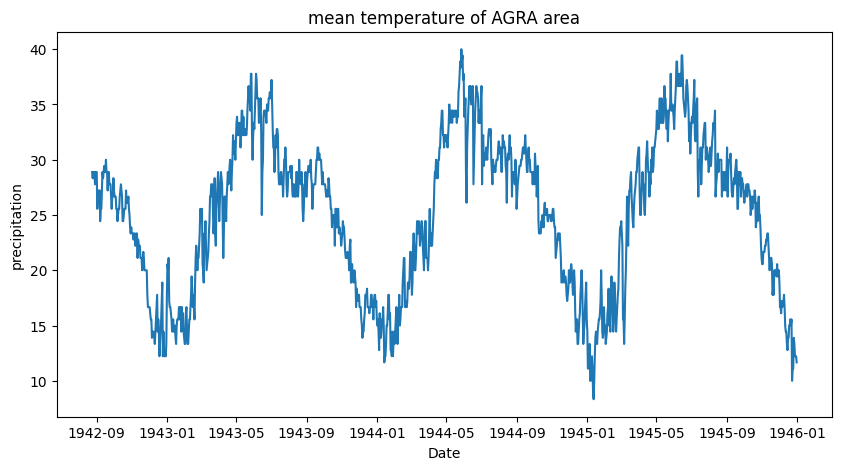

In [6]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [7]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

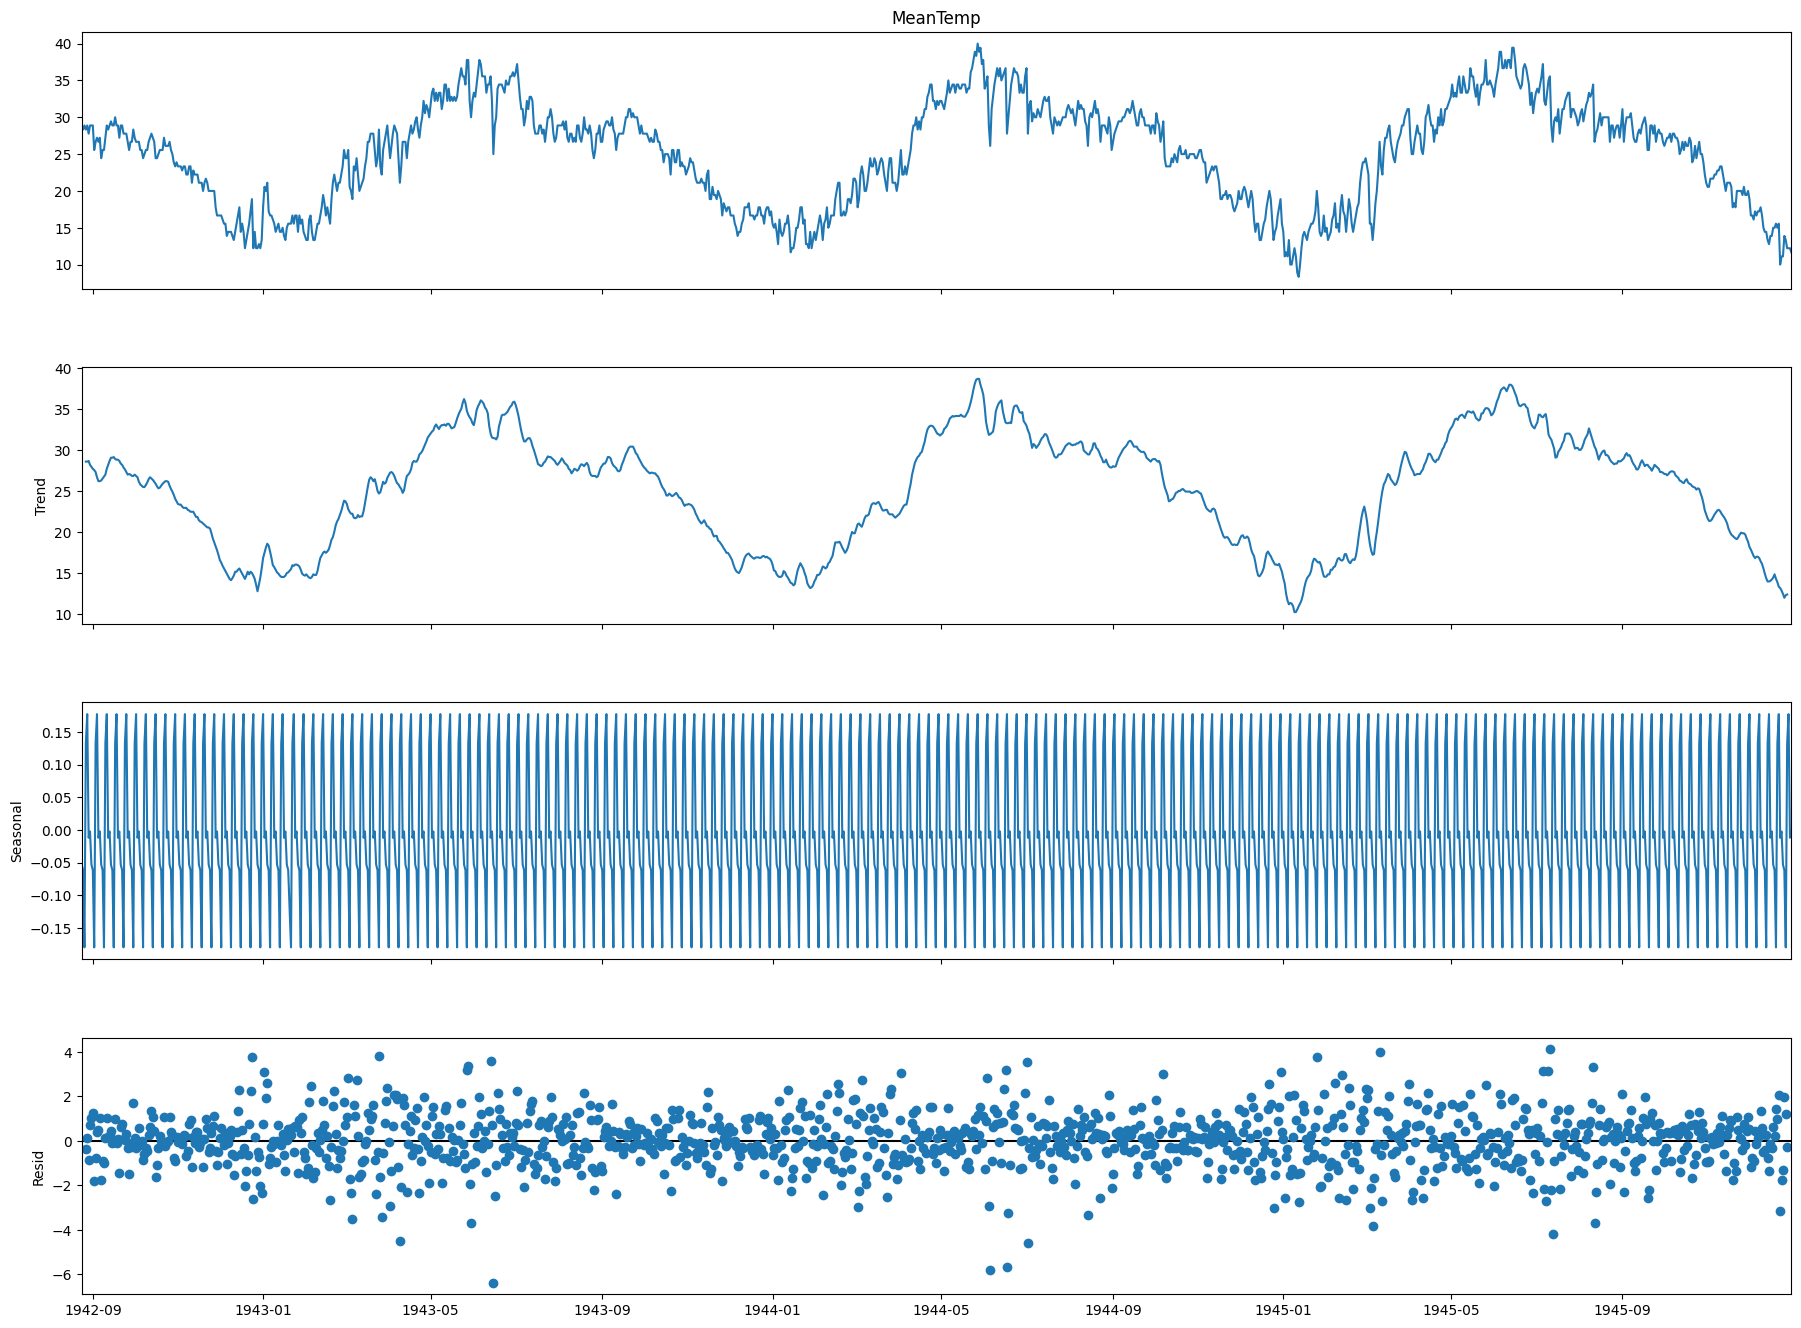

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

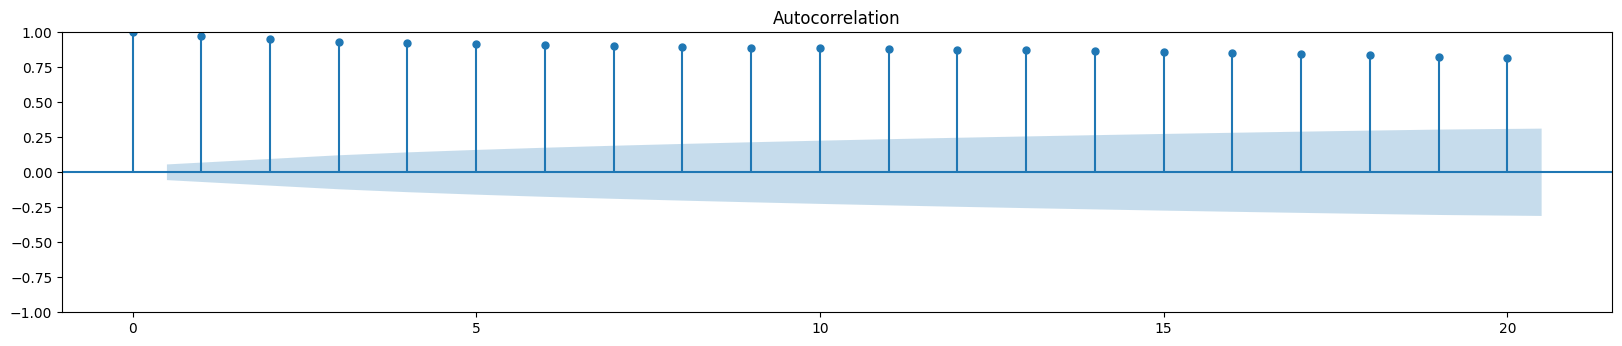

In [9]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [10]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.

A1. p-value가 0.259885로 유의수준 0.05보다 크기 때문에 "시계열에 단위근이 존재하며 비정상적이다"라는 귀무가설을 기각할 수 없다. 결론적으로 해당 데이터는 정상성을 만족하지 않는 비정상 시계열임을 알 수 있다.

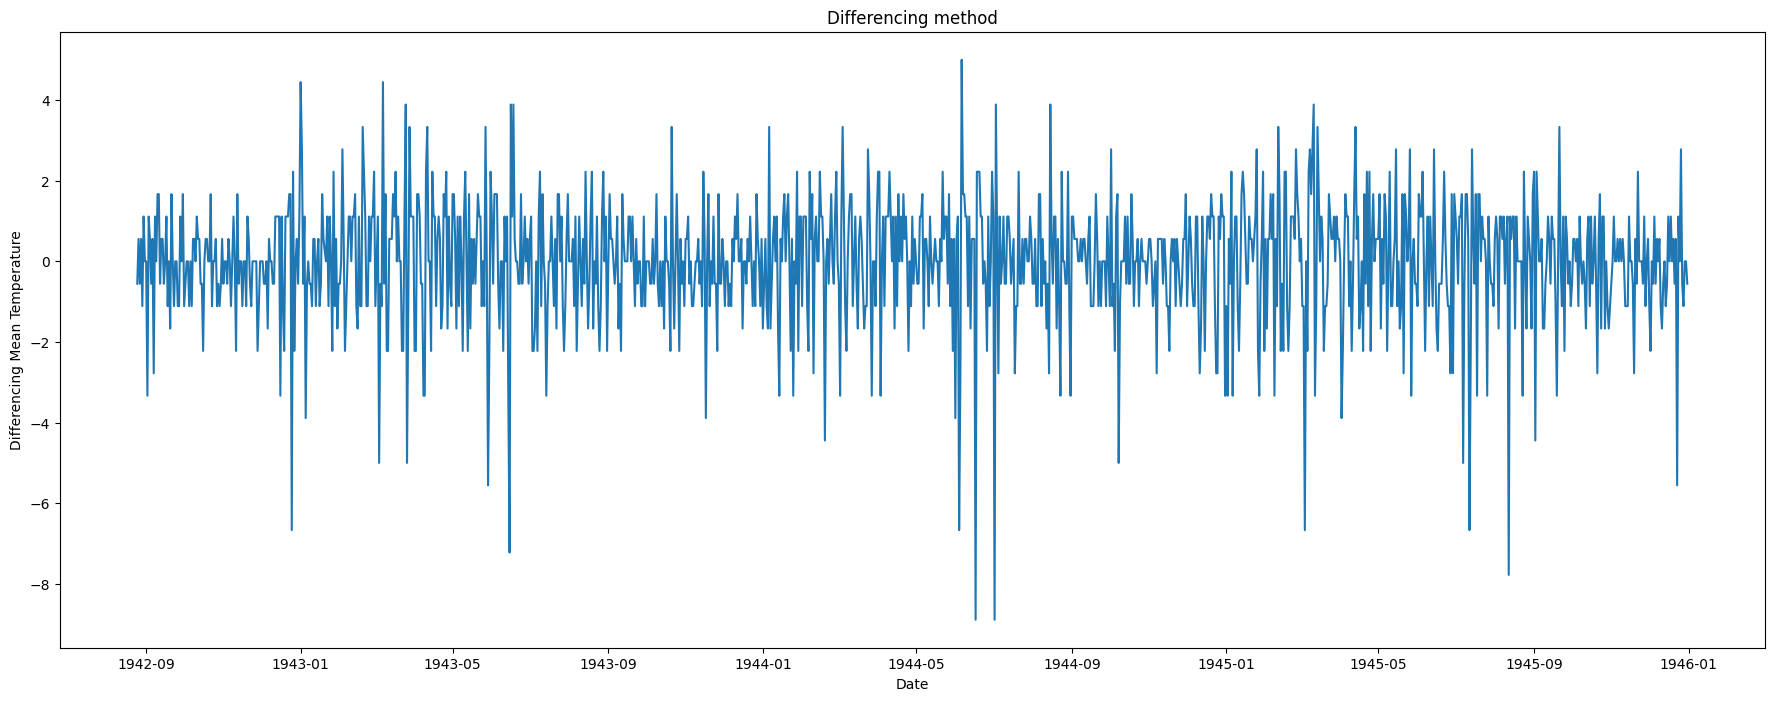

In [ ]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [ ]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2. 이전의 $\text{p-value}$($0.259885$)가 유의수준 $0.05$보다 낮아져, '단위근이 존재한다(비정상)'는 귀무가설을 기각하고 '정상성을 만족한다'는 대립가설을 채택하게 된다. 또한 $\text{ADF Statistic}$ 값의 절대값이 커지며 임계값(Critical Values)보다 작아지게 되어 시계열이 정상 상태가 되었음을 나타낸다.<br> 이는 원 시계열에 존재하던 추세(Trend)나 시간에 따라 변하는 평균 성분이 차분 과정을 통해 제거되었기 때문이다. 이를 통해 평균을 일정하게 유지시켜 비정상 시계열을 정상 시계열로 변환한다.

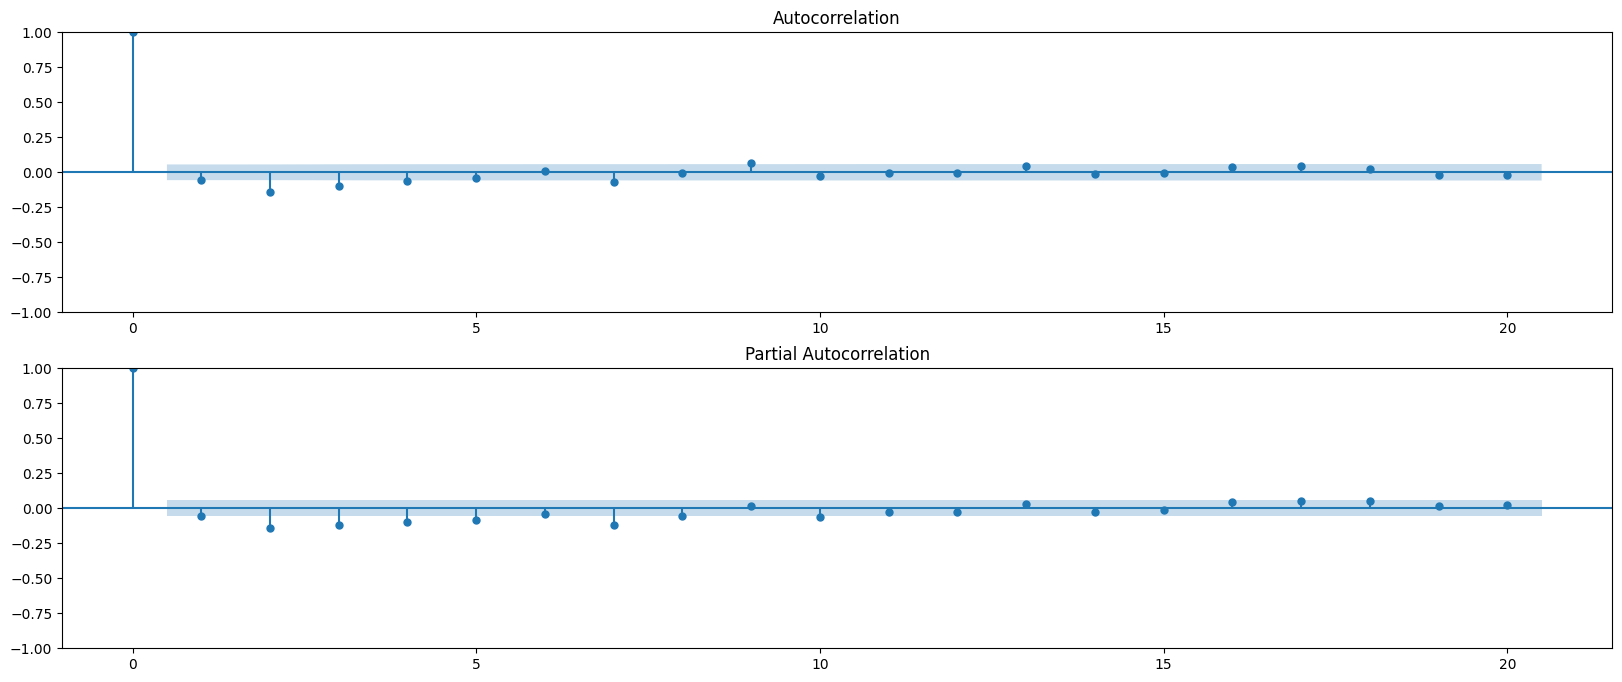

In [ ]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인

*   항목 추가
*   항목 추가

p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3.
- $p = 5$: PACF가 lag 5까지 유의미하게 신뢰구간 밖. 이후 간헐적으로 신뢰구간 밖의 점들이 보이긴 하나 전체적으로 봤을 때 lag 5에서 cut-off하는 형태로 볼 수 있음.
- $q = 3$: ACF가 lag 3까지 유의미하게 신뢰구간 밖. 이후 간헐적으로 신뢰구간 밖의 점들이 보이긴 하나 전체적으로 봤을 때 lag 3에서 cut-off하는 형태로 볼 수 있음.

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

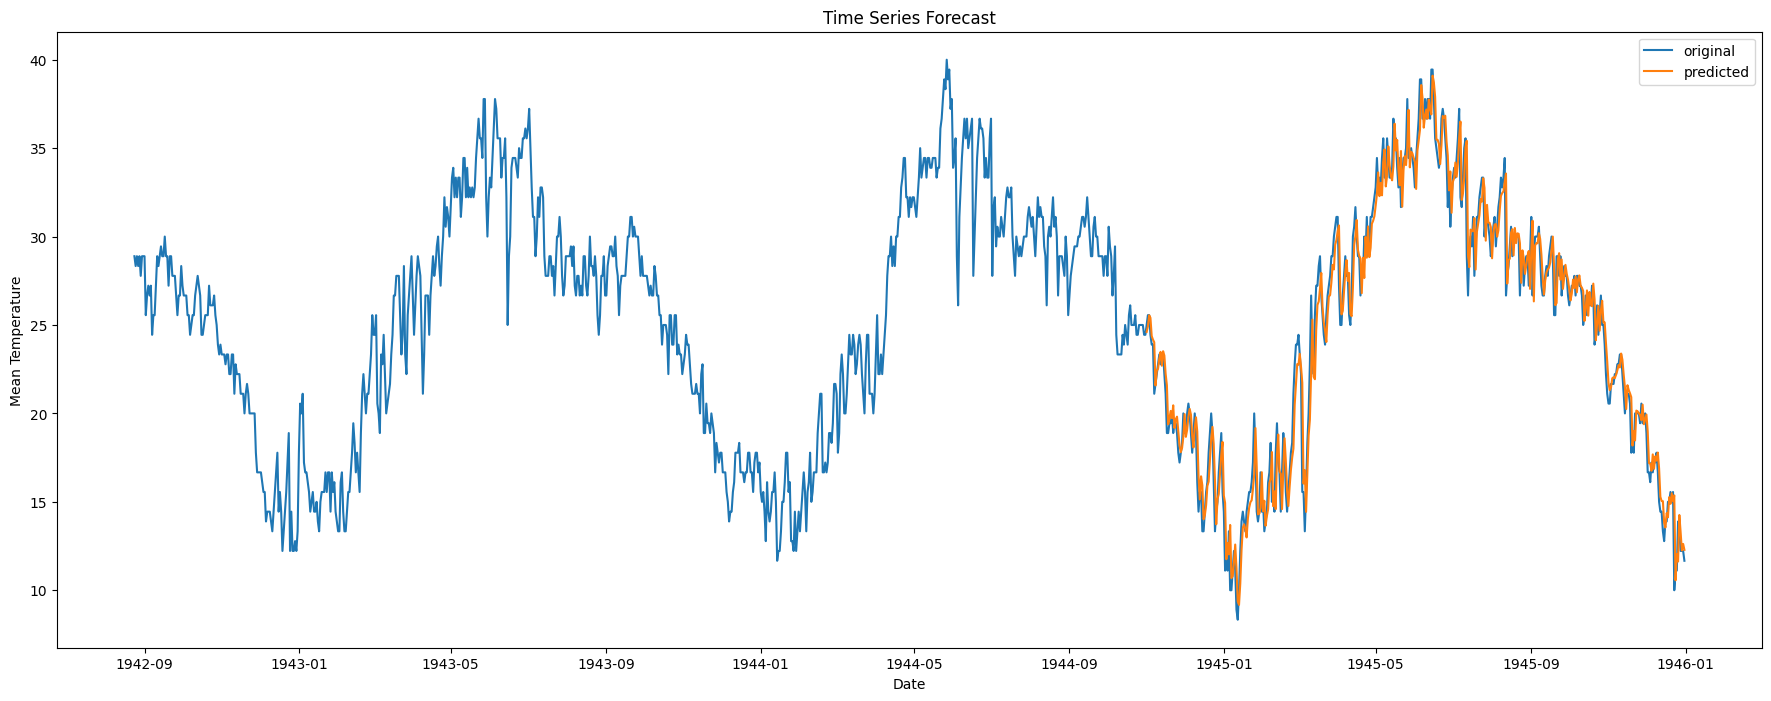

In [17]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p =5
d =1
q =3

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_1111/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


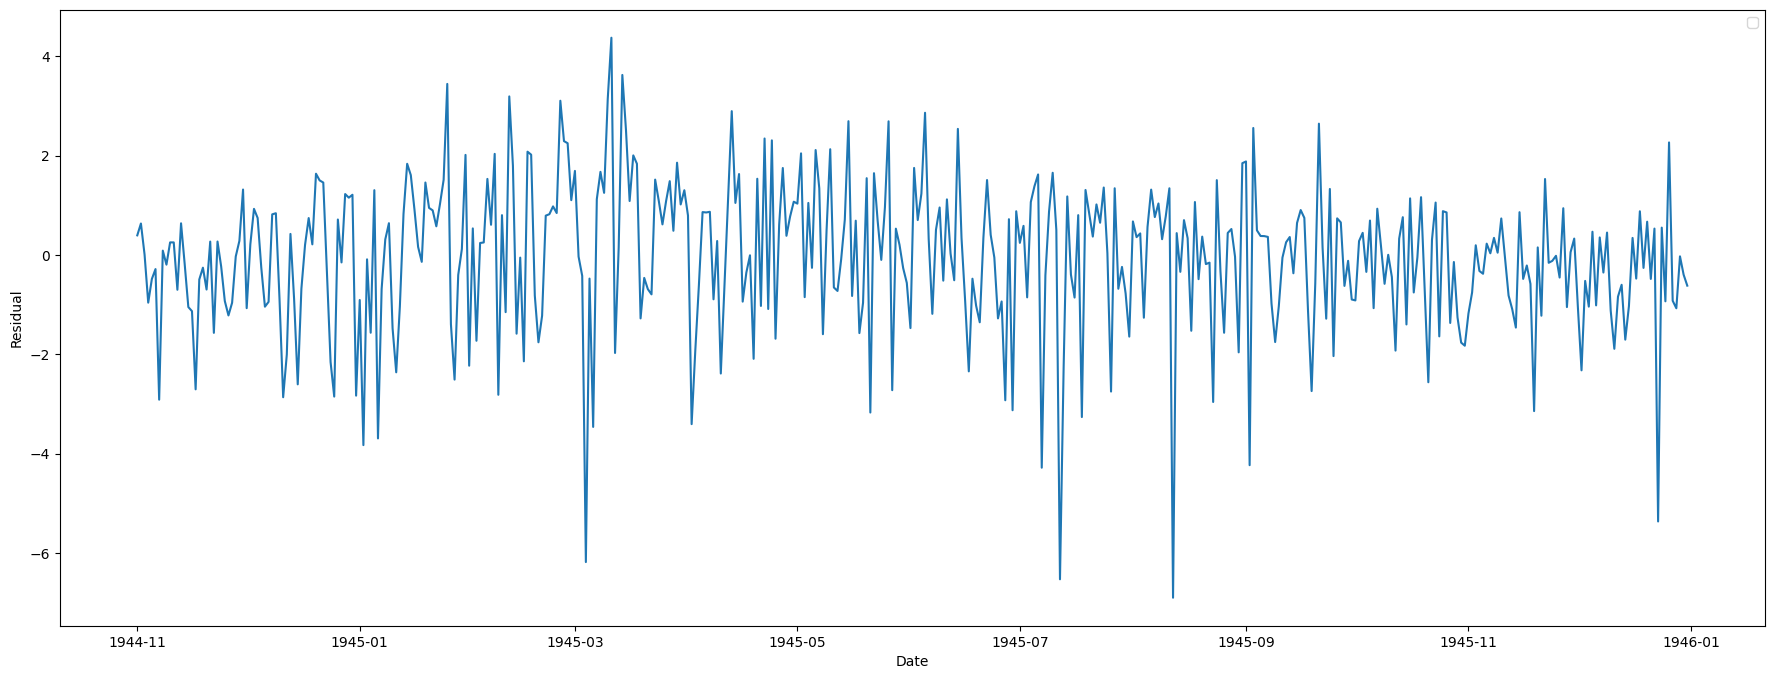

In [18]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

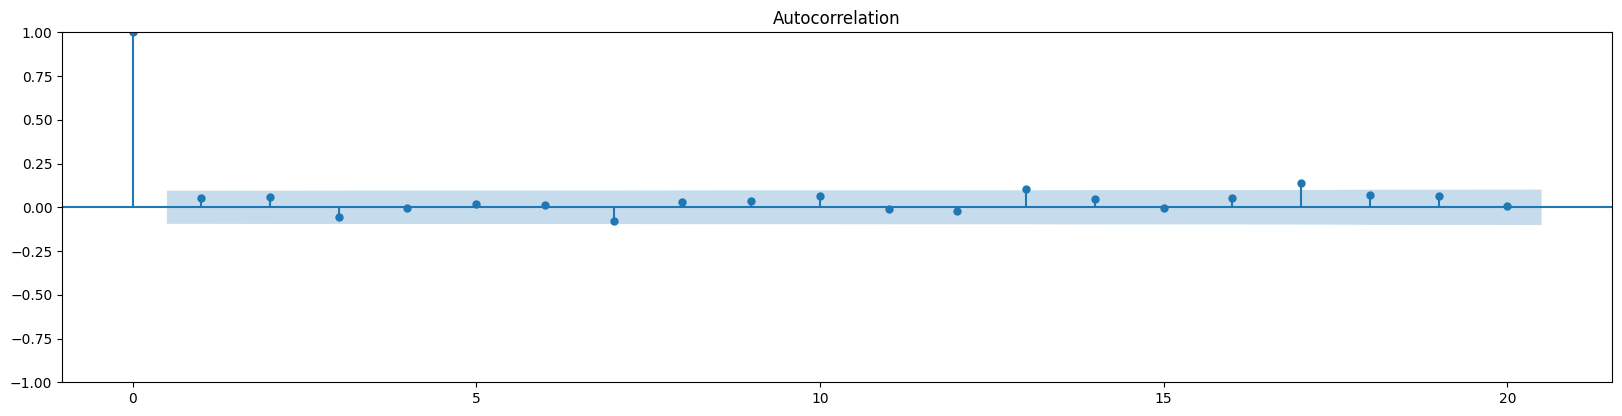

In [19]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [20]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -19.535021
p-value: 0.000000
Critical Values:
	1%: -3.446
	5%: -2.868
	10%: -2.570


In [21]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [22]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.916,0.979,1.501,5.282


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4. ARIMA(5, 1, 3) 모델은 1944년 11월 ~ 1945년 12월의 기온 시계열을 매우 높은 정확도로 예측하고 있다.
- ADF 검정 결과 잔차에 더 이상 자기상관 구조가 남아있지 않아, 모델이 시계열의 패턴을 충분히 학습했음을 알 수있고,
- R² 95.9%, Corr 0.979로 실제 기온 변동을 거의 그대로 추적했음을 알 수 있다.
- RMSE 1.5°C, MAPE 5.28%로 실용적으로 활용 가능한 수준의 낮은 오차를 갖는다.

### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4. Grid Search를 통해 최적의 파라미터를 탐색한 결과, 최적 파라미터는 다음과 같았다. <br> {'kernel_size': 25, 'lr': 0.001, 'epochs': 100}  (Val MSE=0.007618)
해당 파라미터를 최적 파라미터라고 판단한 근거는 Validation MSE가 가장 낮았기 때문이다. 최적 파라미터의 최종 성능은 다음과 같았는데, <br>
최종 성능:
|      | R2  | Corr |  RMSE  | MAPE |
|-|-|-|-|-|
|0 | 84.544 | 0.925 | 2.714 | 8.594|

이를 위에서 실행한 ARIMA 분석과 비교했을 때, 모든 성능 지표에서 ARIMA가 우세하므로, ARIMA 모델이 더 적합하다고 볼 수 있다.

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
data = ts.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [25]:
seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [26]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=365):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [27]:
# @title
model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 10

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.007421


## **Grid Search 방식을 통한 최적 파라미터 결정**

In [31]:
from itertools import product
import pandas as pd

param_grid = {
    'kernel_size': [25, 51, 125],
    'lr':          [0.001, 0.005, 0.01],
    'epochs':      [50, 100],
}

results     = []
best_mse    = float('inf')
best_params = None

combos = list(product(*param_grid.values()))
keys   = list(param_grid.keys())
total  = len(combos)

print(f"총 {total}개 조합 탐색 시작\n{'='*55}")

for i, combo in enumerate(combos, 1):
    params = dict(zip(keys, combo))
    ks, lr, ep = params['kernel_size'], params['lr'], params['epochs']
    print(f"[{i:>2}/{total}] kernel={ks}, lr={lr}, epochs={ep}", end="  →  ")

    # ──  train_loader 그대로 재활용 ──
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

    model     = DLinear(seq_len, pred_len, kernel_size=ks).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(ep):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y.squeeze(-1))
            loss.backward()
            optimizer.step()

    # ──  test_scaled로 walk-forward 예측 ──
    model.eval()
    predictions    = []
    current_window = train_scaled[-seq_len:].copy()
    total_test_len = len(test_scaled)

    while len(predictions) < total_test_len:
        x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(x).cpu().numpy().flatten()
        remaining = total_test_len - len(predictions)
        pred = pred[:remaining]
        predictions.extend(pred)
        current_window = np.concatenate(
            [current_window[pred_len:], pred.reshape(-1, 1)], axis=0
        )

    val_mse = np.mean((test_scaled.flatten() - np.array(predictions)) ** 2)
    print(f"Val MSE: {val_mse:.6f}")
    results.append({**params, 'val_mse': val_mse})

    if val_mse < best_mse:
        best_mse    = val_mse
        best_params = params

# ── 결과 출력 ────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('val_mse').reset_index(drop=True)
print(f"\n{'='*55}")
print("🏆 상위 5개 결과:")
print(results_df.head())
print(f"\n✅ 최적 파라미터: {best_params}  (Val MSE={best_mse:.6f})")


# ── 최적 파라미터로 최종 학습 후 기존 scoring() 호출 ─────────
ks, lr, ep = best_params['kernel_size'], best_params['lr'], best_params['epochs']

model     = DLinear(seq_len, pred_len, kernel_size=ks).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(ep):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss   = criterion(output, y.squeeze(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

# ──  walk-forward + scoring()  ─────────────────────
model.eval()
predictions    = []
current_window = train_scaled[-seq_len:].copy()
total_test_len = len(test_scaled)

while len(predictions) < total_test_len:
    x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x).cpu().numpy().flatten()
    remaining = total_test_len - len(predictions)
    pred = pred[:remaining]
    predictions.extend(pred)
    current_window = np.concatenate(
        [current_window[pred_len:], pred.reshape(-1, 1)], axis=0
    )

forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

y_true = ts.values[train_size:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(f"\n📊 최적 파라미터 {best_params} 최종 성능:")
print(scoring(y_true, y_pred))

총 18개 조합 탐색 시작
[ 1/18] kernel=25, lr=0.001, epochs=50  →  Val MSE: 0.008081
[ 2/18] kernel=25, lr=0.001, epochs=100  →  Val MSE: 0.007618
[ 3/18] kernel=25, lr=0.005, epochs=50  →  Val MSE: 0.022255
[ 4/18] kernel=25, lr=0.005, epochs=100  →  Val MSE: 0.014571
[ 5/18] kernel=25, lr=0.01, epochs=50  →  Val MSE: 0.022175
[ 6/18] kernel=25, lr=0.01, epochs=100  →  Val MSE: 0.015779
[ 7/18] kernel=51, lr=0.001, epochs=50  →  Val MSE: 0.008621
[ 8/18] kernel=51, lr=0.001, epochs=100  →  Val MSE: 0.008996
[ 9/18] kernel=51, lr=0.005, epochs=50  →  Val MSE: 0.019175
[10/18] kernel=51, lr=0.005, epochs=100  →  Val MSE: 0.018987
[11/18] kernel=51, lr=0.01, epochs=50  →  Val MSE: 0.019517
[12/18] kernel=51, lr=0.01, epochs=100  →  Val MSE: 0.074082
[13/18] kernel=125, lr=0.001, epochs=50  →  Val MSE: 0.008046
[14/18] kernel=125, lr=0.001, epochs=100  →  Val MSE: 0.008028
[15/18] kernel=125, lr=0.005, epochs=50  →  Val MSE: 0.015081
[16/18] kernel=125, lr=0.005, epochs=100  →  Val MSE: 0.016124
[

In [28]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

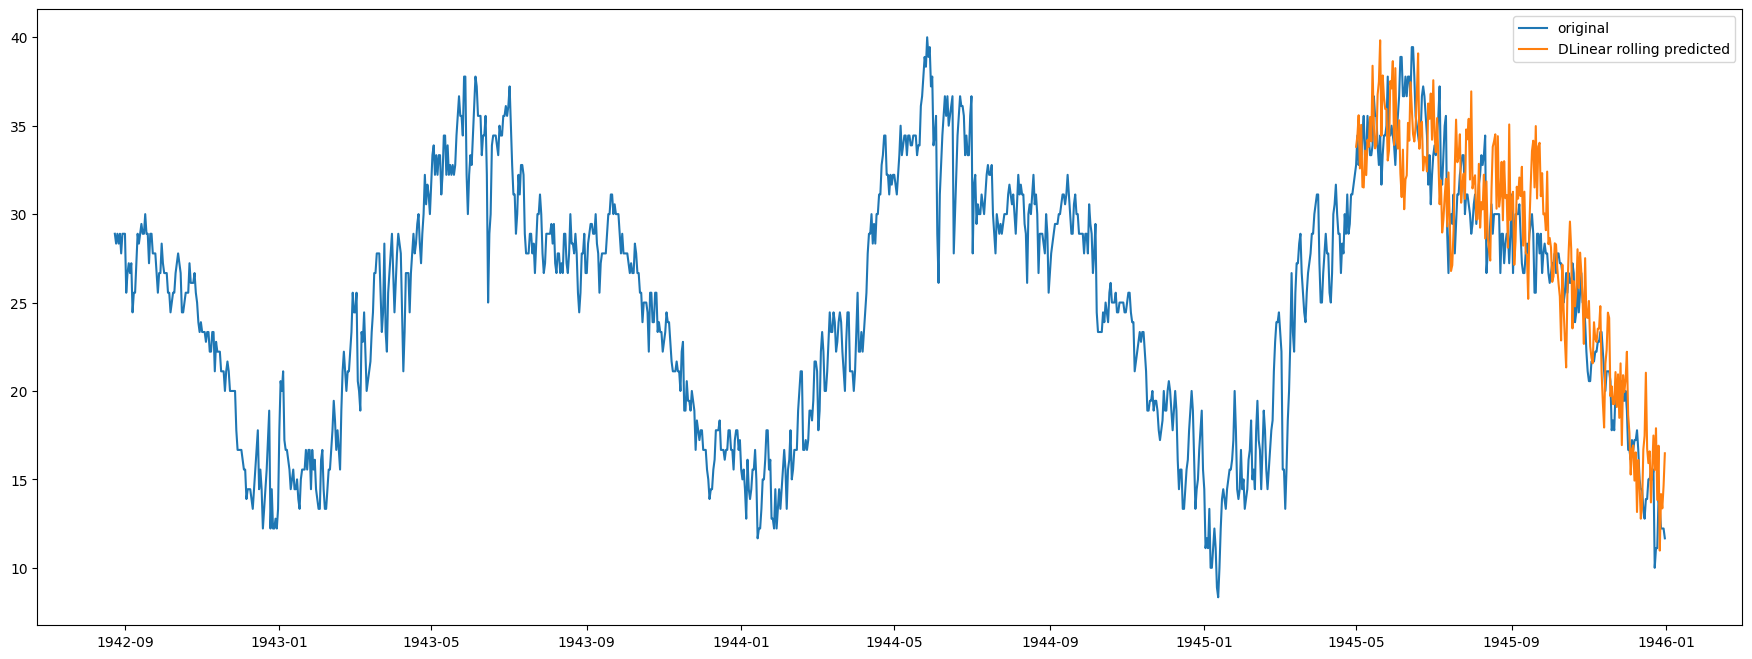

In [29]:
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")

test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [30]:
test_start_idx = train_size

y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(245,) (245,)


,R2,Corr,RMSE,MAPE
0,80.037,0.903,3.085,9.629


## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [35]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()
pd.set_option('display.max_rows', None)

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
AMBERLY,848
AMURI/FIELD AAF,884
ATAR,876
BALBOA/ALBROOK,2185
BAMRAULI,868
BANGALORE,1180
BERMUDA,1487


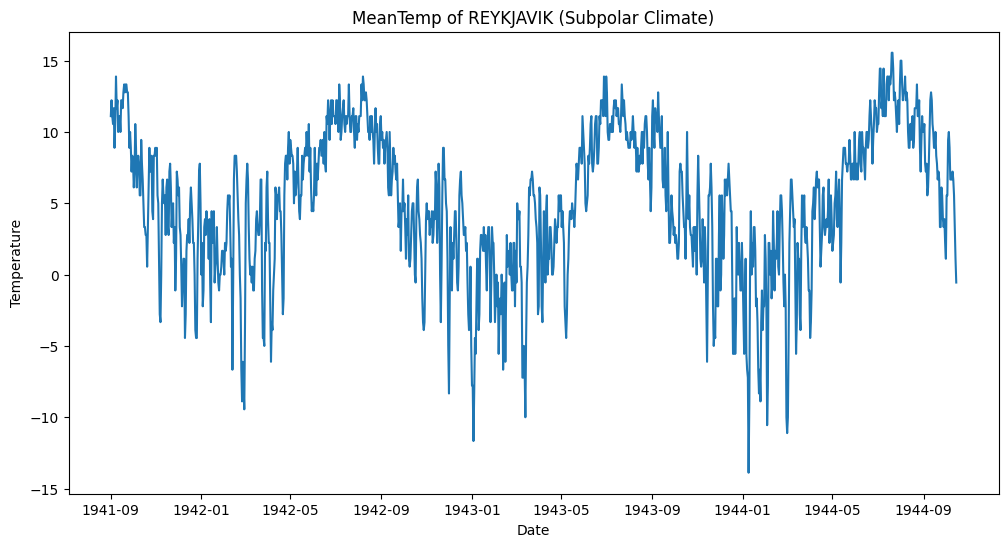

In [36]:
#=============================
#1. 데이터 추출 및 기초 시각화
#=============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 도시: 'REYKJAVIK', 분석 요인: 'MeanTemp'
city_name = "REYKJAVIK"
target_factor = "MeanTemp"

# loc_df에서 REYKJAVIK의 WBAN(관측소 ID) 추출
loc_sta = loc_df[loc_df["NAME"] == city_name].WBAN
weather_bin_rk = weather_df[weather_df.STA == int(loc_sta.iloc[0])].copy()

# 날짜 데이터 처리 및 시계열 객체 생성
weather_bin_rk["Date"] = pd.to_datetime(weather_bin_rk["Date"])
timeSeries_rk = weather_bin_rk.loc[:, ["Date", target_factor]]
timeSeries_rk.index = timeSeries_rk["Date"]
ts_rk = timeSeries_rk.drop("Date", axis=1).dropna()

# 데이터 분포 시각화
plt.figure(figsize=(12, 6))
plt.plot(ts_rk.index, ts_rk[target_factor])
plt.title(f"{target_factor} of {city_name} (Subpolar Climate)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

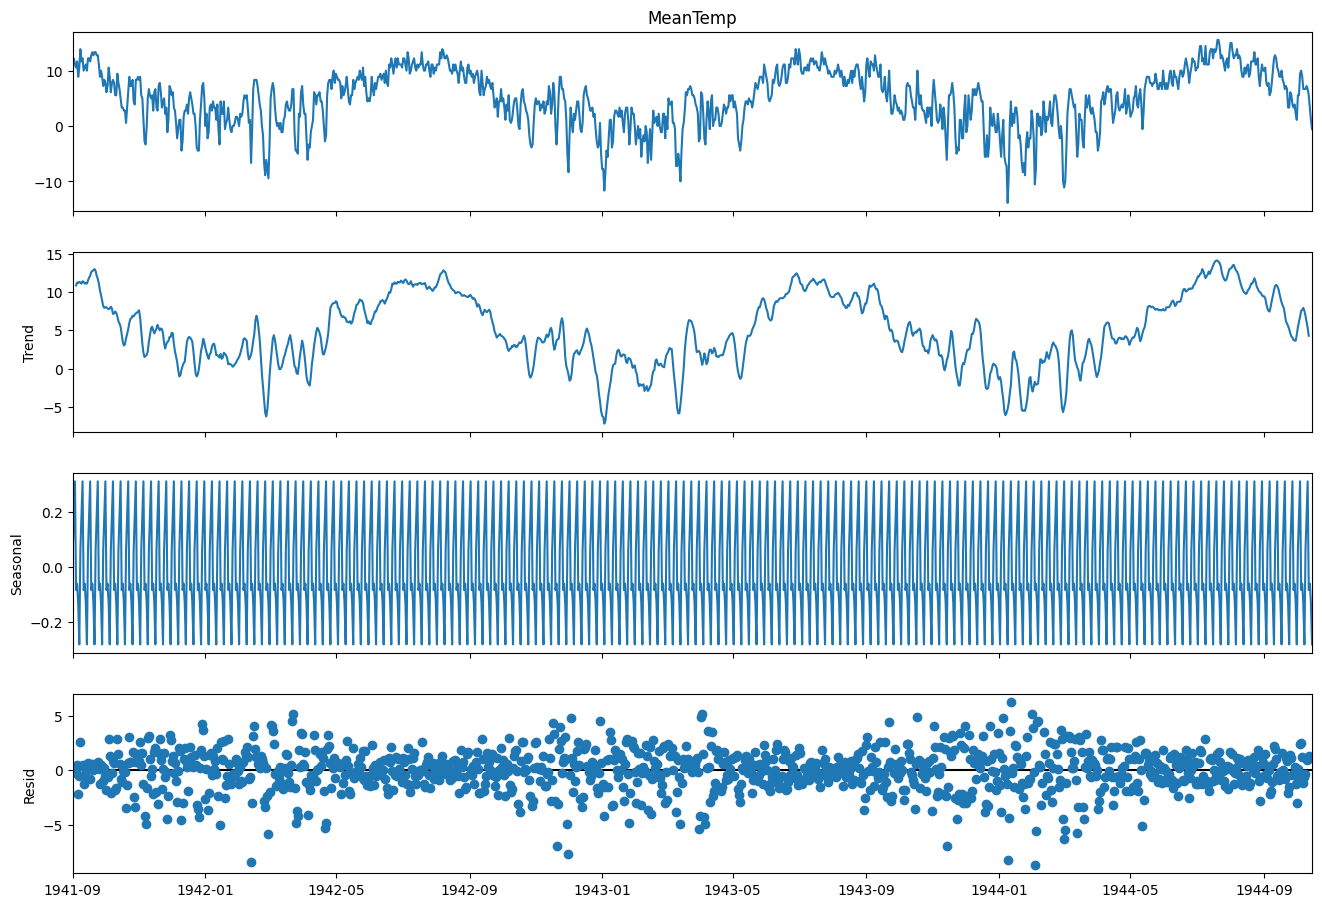

--- REYKJAVIK Original ADF Test ---
p-value: 0.047711

--- REYKJAVIK 1st Differencing ADF Test ---
p-value: 0.000000


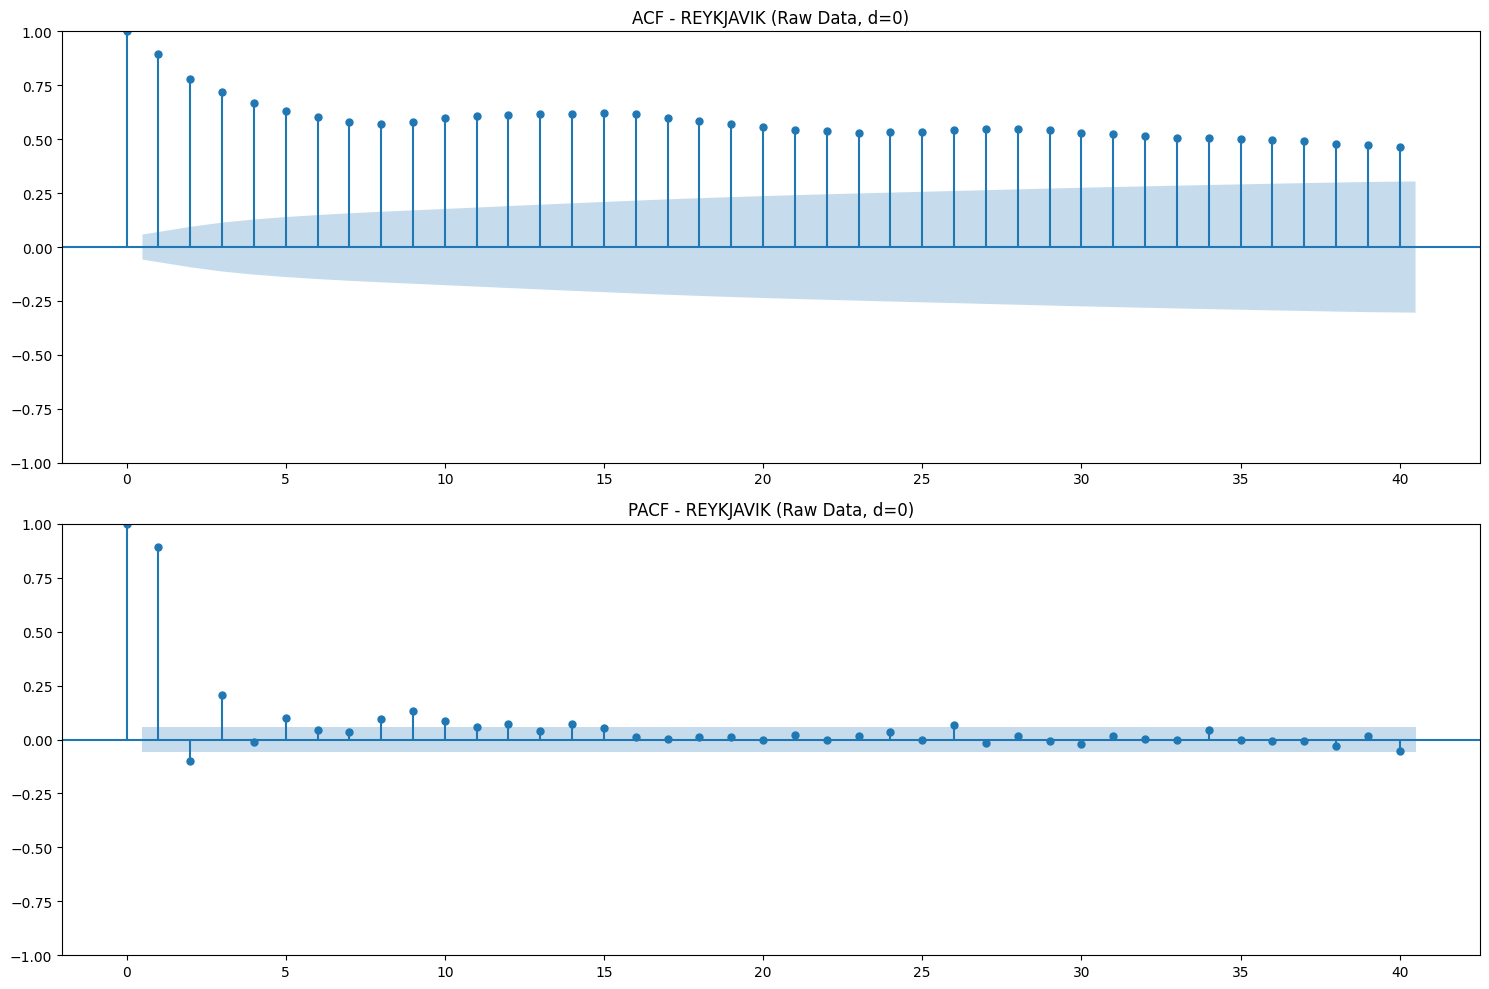

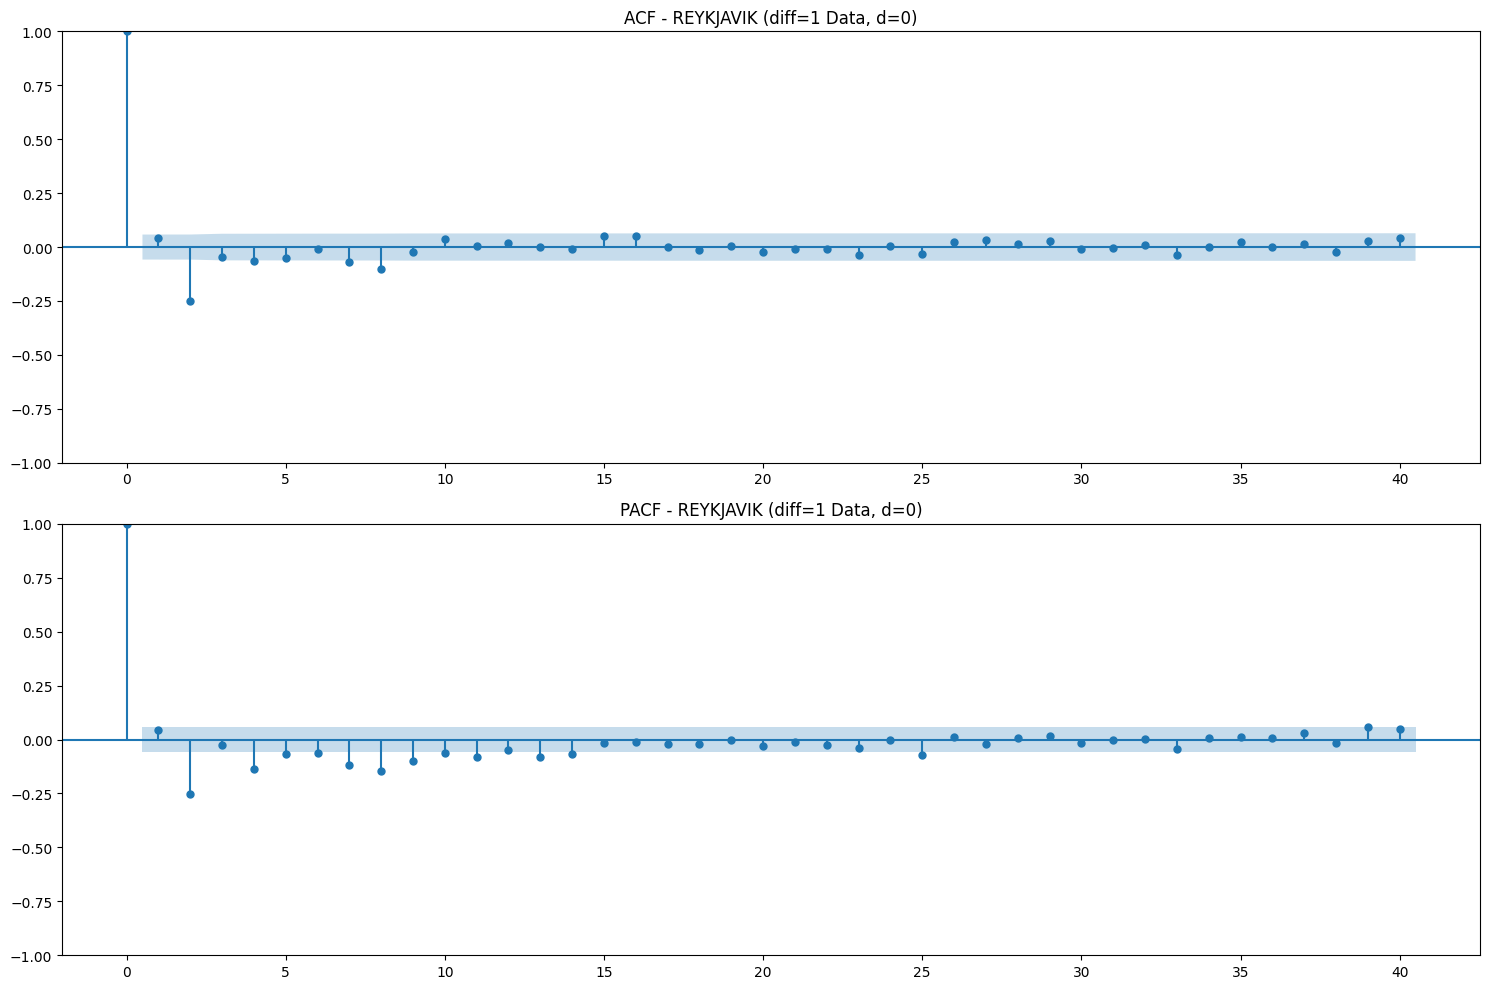

In [39]:
#=============================
#2. 시계열 분해 및 정상성 검정
#=============================
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

# 1. 시계열 구성요소 분리 (주기 7일 가정)
result_rk = seasonal_decompose(ts_rk[target_factor], model='additive', period=7)
fig = result_rk.plot()
fig.set_size_inches(15, 10)
plt.show()

# 2. 원본 데이터 ADF 검정
print(f"--- {city_name} Original ADF Test ---")
res_adf = adfuller(ts_rk)
print(f'p-value: {res_adf[1]:.6f}')

# 3. 1차 차분 수행 및 재검정
ts_diff_rk = (ts_rk - ts_rk.shift()).dropna()
print(f"\n--- {city_name} 1st Differencing ADF Test ---")
res_diff_adf = adfuller(ts_diff_rk)
print(f'p-value: {res_diff_adf[1]:.6f}')

# 4-1. ACF / PACF 시각화 (원본 데이터)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# 원본 데이터(ts_rk) 사용
sm.graphics.tsa.plot_acf(ts_rk, lags=40, ax=ax1)
sm.graphics.tsa.plot_pacf(ts_rk, lags=40, ax=ax2)

ax1.set_title(f"ACF - {city_name} (Raw Data, d=0)")
ax2.set_title(f"PACF - {city_name} (Raw Data, d=0)")
plt.tight_layout()
plt.show()

# 4-2. ACF / PACF 시각화 (1차 차분 후 데이터)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
sm.graphics.tsa.plot_acf(ts_diff_rk, lags=40, ax=ax1)
sm.graphics.tsa.plot_pacf(ts_diff_rk, lags=40, ax=ax2)

ax1.set_title(f"ACF - {city_name} (diff=1 Data, d=0)")
ax2.set_title(f"PACF - {city_name} (diff=1 Data, d=0)")
plt.tight_layout()
plt.show()

ADF 검정만 진행했을 땐 원본 시계열의 p-value 값이 0.05 이하였기에 원본 시계열을 정상 시계열로 판단할 수 있었으나, ACF와 PACF 그래프를 그려본 결과, 원본 시계열의 ACF가 매우 천천히 감소한다. 따라서, 1차 차분 데이터가 모델링에 더 적절하다.
<br>ACF 그래프는 Lag 2에서 유의한 스파이크 후 급절단되므로 q=2가 적절해보이고,
PACF 그래프는 Lag 2 이후 서서히 감소하므로 p = 0가 적절해보인다.
<br> 따라서 최종적인 모델은 ARIMA(0,1,2)가 적절하다고 판단할 수 있다.




--- REYKJAVIK ARIMA 파라미터 최적화 시작 ---
✅ 최적의 파라미터: ARIMA(1, 1, 3) (AIC: 4978.28)


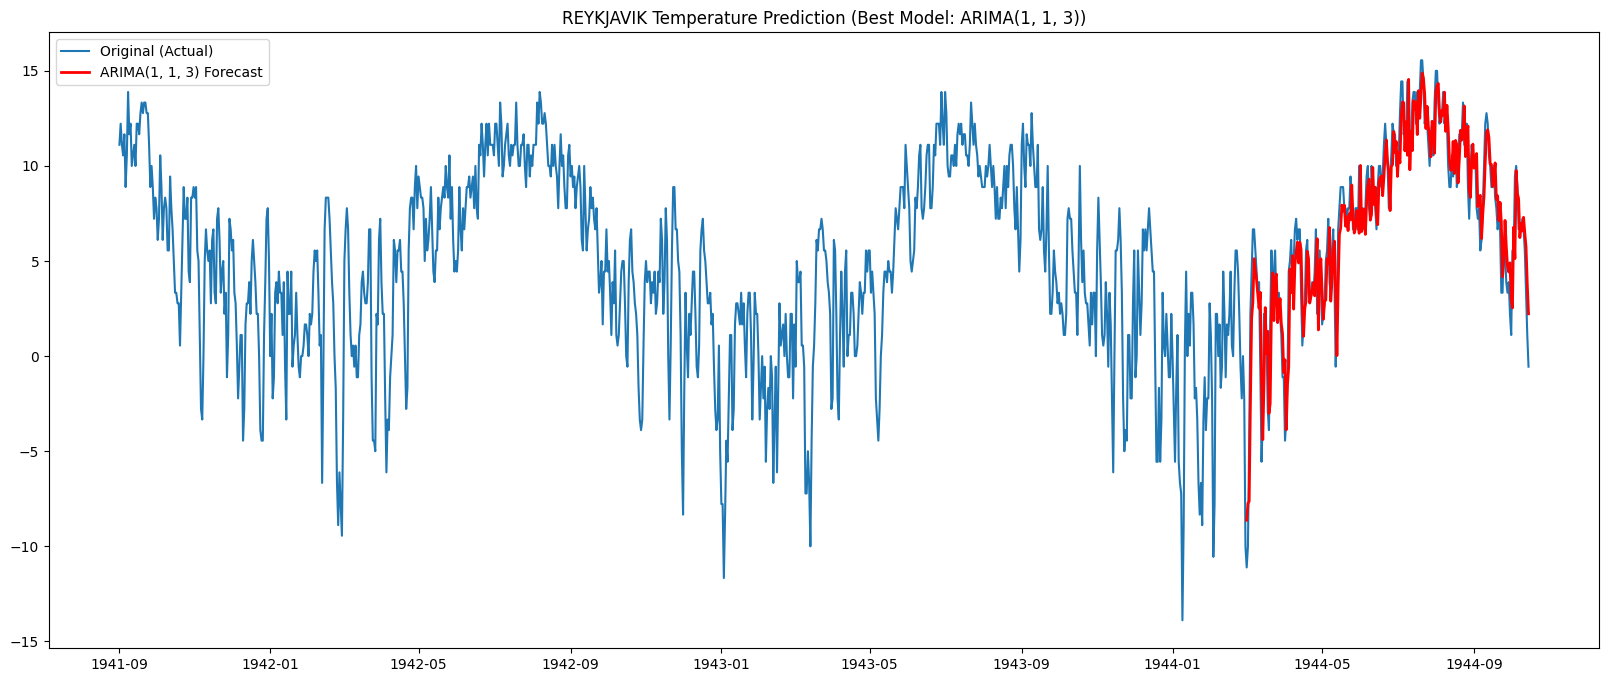


📊 최적 모델 성능 지표:
       R2   Corr  RMSE    MAPE
0  85.442  0.926  1.76  37.331


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# 경고 무시 및 세팅
warnings.filterwarnings("ignore")


target_data = ts_rk[target_factor]

p_range = range(0, 4)
d = 1  # ACF가 천천히 감소하므로 차분 1 유지
q_range = range(0, 4)

best_aic = float("inf")
best_pdq = None
best_model_fit = None

print("--- REYKJAVIK ARIMA 파라미터 최적화 시작 ---")

for p_val in p_range:
    for q_val in q_range:
        try:
            # enforce_stationarity, enforce_invertibility를 False로 두어 수렴 가능성 증대
            temp_model = ARIMA(target_data, order=(p_val, d, q_val),
                               enforce_stationarity=False,
                               enforce_invertibility=False)
            temp_model_fit = temp_model.fit()
            current_aic = temp_model_fit.aic

            if current_aic < best_aic:
                best_aic = current_aic
                best_pdq = (p_val, d, q_val)
                best_model_fit = temp_model_fit
        except Exception as e:
            # 어떤 에러로 실패하는지 확인하고 싶다면 아래 주석 해제
            # print(f"ARIMA({p_val}, {d}, {q_val}) 실패: {e}")
            continue

# 결과 체크 및 언패킹
if best_pdq is None:
    print(" 모든 조합에서 모델 학습에 실패했습니다. 데이터를 다시 확인해주세요.")
else:
    print(f"✅ 최적의 파라미터: ARIMA{best_pdq} (AIC: {best_aic:.2f})")
    p, d, q = best_pdq

    # 예측 수행
    split_idx = int(len(ts_rk) * 0.8)
    start_date = ts_rk.index[split_idx]
    end_date = ts_rk.index[-1]
    forecast_rk = best_model_fit.predict(start=start_date, end=end_date)

    # 시각화
    plt.figure(figsize=(20, 8))
    plt.plot(ts_rk.index, target_data, label="Original (Actual)")
    plt.plot(forecast_rk.index, forecast_rk, label=f"ARIMA{best_pdq} Forecast", color='red', linewidth=2)
    plt.title(f"{city_name} Temperature Prediction (Best Model: ARIMA{best_pdq})")
    plt.legend()
    plt.show()

    # 성능 지표 출력
    print("\n📊 최적 모델 성능 지표:")
    y_true = target_data[start_date:end_date].values
    y_pred = forecast_rk.values
    print(scoring(y_true, y_pred))

실습 1의 인도 AGRA와 추가 분석한 아이슬란드 REYKJAVIK의 시계열 분석 결과를 비교하여, 데이터의 기후 특성이 모델링 및 평가에 미치는 영향을 다음과 같이 도출하였다.
1. 기후 변동성에 따른 정상성(Stationarity)과 모델 복잡도의 차이고온 다습하며 외부 요인이 잦은 AGRA는 기온 변동폭이 커 강한 비정상성을 띠므로 1차 이상의 차분이 필수적이었으며, $ARIMA(5, 1, 3)$과 같은 복잡한 모델이 요구되었다. 반면, 기온 변화가 완만하고 평균 회귀 성향이 강한 REYKJAVIK은 원본 데이터의 $p$-value가 $0.047$로 정상성 기준을 충족하였고, 단순한 파라미터만으로도 전체 흐름을 충분히 학습하였다. 즉, 분석 대상의 환경적 복잡도가 낮을수록 시계열 모델의 구조 역시 단순해짐을 확인하였다.
2. 스케일(Scale) 차이로 인한 평가지표의 왜곡REYKJAVIK 최적 모델의 성능 지표는 $R^2$ $85.442$, $RMSE$ $1.76$, $MAPE$ $37.331$로 산출되었다. 절대 오차인 $RMSE$는 AGRA($1.50$)와 유사한 수준이나, 비율 오차인 $MAPE$는 비정상적으로 높게 나타났다. 이는 레이캬비크의 실제 기온이 $0$도에 인접해 있어, 실제값을 분모로 사용하는 $MAPE$의 특성상 미세한 오차에도 값이 극단적으로 과대평가되기 때문이다. 따라서 한랭 기후 등 데이터가 $0$ 부근을 오르내리는 경우, $MAPE$에 대한 의존을 줄이고 $RMSE$ 및 $R^2$를 종합적으로 고려해야 객관적인 분석이 가능하다.